# Financial Data Analytics (FDA) - Assignment 2
## Exploratory Data Analysis, Outlier Analysis, and Clustering-Based Anomaly Detection
**Coursework Submission**

---
### Dataset Understanding & Adaptation Notice
* **Original Notebook Context:** The starter notebook template originally referenced `Fraud Detection Dataset.csv` containing columns: `Fraudulent`, `Payment_Method`, `Transaction_Amount`, `Previous_Fraudulent_Transactions`, `Account_Age`, `Number_of_Transactions_Last_24H`, and `Time_of_Transaction`.
* **Available Dataset:** The provided dataset is `creditcard.csv`, which contains 284,807 European credit card transactions recorded over 48 hours, consisting of continuous features `Time`, `Amount`, 28 PCA-transformed numerical components (`V1` to `V28`), and the binary ground-truth label `Class` (0 = Legitimate, 1 = Fraud).
* **Task Adaptations & Methodological Rationale:**
  1. **Column Name Mappings:**
     - Target variable `Fraudulent` is mapped directly to `Class`.
     - `Transaction_Amount` is mapped directly to `Amount`.
     - `Time_of_Transaction` is mapped directly to `Time` (and derived `Hour` / `Time_Period`).
  2. **Payment Method / Categorical Feature Clustering (`Task 2`):** In the absence of an explicit `Payment_Method` column, we adapt this task to **Transaction Profile & Behavioral Clustering vs. Fraudulent (`Class`)**. Transactions are segmented into financial and temporal tiers (`Amount_Tier` and `Time_Period`), examining how fraud risk clusters across payment sizes and operating periods.
  3. **Feature Selection for DBSCAN Anomaly Detection (`Tasks 4 & 5`):** The synthetic columns (`Previous_Fraudulent_Transactions`, etc.) do not exist. We evaluate and select the principal components that carry the genuine latent fraud and behavioral signatures:
     - **Feature Set 1:** `['Amount', 'V14', 'V17', 'V12']` (highest inverse correlation with fraud).
     - **Feature Set 2:** `['Amount', 'V4', 'V10', 'V11']` (strong positive/negative discriminant components).
  4. **Scaling & Computational Scalability:**
     - `RobustScaler` is selected over `StandardScaler` because `Amount` contains extreme outliers (up to $25,691.16 vs median $22.00) that would severely distort mean and standard deviation.
     - Direct DBSCAN on the full 284,807 rows is computationally intractable ($O(N^2)$ distance matrix requires $\approx 648$ GB RAM). We resolve this academically by performing parameter tuning (k-distance graph) and density clustering on a representative class-stratified sample ($N=10,000$), preserving the authentic 0.173% fraud prevalence while ensuring fast, reproducible execution.
---

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Set visual aesthetic
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the transaction dataset
df = pd.read_csv("creditcard.csv")

print(f"Dataset Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage().sum() / (1024**2):.2f} MB")
df.head()

Dataset Dimensions: 284,807 rows x 31 columns
Memory Usage: 67.36 MB


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Inspect available features
print("Columns list:")
print(df.columns.tolist())

print("\nData Types Summary:")
print(df.dtypes.value_counts())

Columns list:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types Summary:
float64    30
int64       1
Name: count, dtype: int64


In [4]:
initial_rows = len(df)
df = df.dropna()
dropped_rows = initial_rows - len(df)

print(f"Initial Rows: {initial_rows:,}")
print(f"Rows after dropna(): {len(df):,}")
print(f"Dropped Null Rows: {dropped_rows}")

Initial Rows: 284,807
Rows after dropna(): 284,807
Dropped Null Rows: 0


In [5]:
missing_percent = df.isnull().mean() * 100

print("Missing Percentage Across Features:")
print(missing_percent[missing_percent > 0] if (missing_percent > 0).any() else "Zero missing values across all 31 features (0.00%).")

Missing Percentage Across Features:
Zero missing values across all 31 features (0.00%).


In [6]:
duplicates = df.duplicated().sum()

print("Full-Row Duplicate Records:", duplicates)
print(f"Duplicate Percentage: {duplicates / len(df) * 100:.3f}%")

Full-Row Duplicate Records: 1081
Duplicate Percentage: 0.380%


**Data Quality Interpretation:**

The dataset contains 284,807 observations with zero missing values across all features. There are 1,081 exact full-row duplicate records, representing approximately 0.380% of the dataset.

The presence of duplicate records indicates that identical transaction records occur in the dataset, but the available data does not provide enough information to determine whether they represent genuine repeated transactions, transaction retries, or data-record duplication.

### Task 1: Column-wise Duplicate Count
**Requirement:** Calculate and display the duplicate value count for each individual column in the dataset.
* **Methodology:** For each feature, the column-wise duplicate count is computed as $\text{Duplicates} = \text{Total Rows} - \text{Unique Values} = N - \text{nunique}()$. We compile this into a summary table and visualize the duplicate frequency across features.

Task 1: Column-wise Duplicate Analysis (Top 12):


,Data_Type,Unique_Count,Duplicate_Count,Duplicate_Percent
Class,int64,2,284805,99.999298
Amount,float64,32767,252040,88.495016
Time,float64,124592,160215,56.253884
V3,float64,275663,9144,3.210595
V4,float64,275663,9144,3.210595
V1,float64,275663,9144,3.210595
V2,float64,275663,9144,3.210595
V7,float64,275663,9144,3.210595
V8,float64,275663,9144,3.210595
V9,float64,275663,9144,3.210595


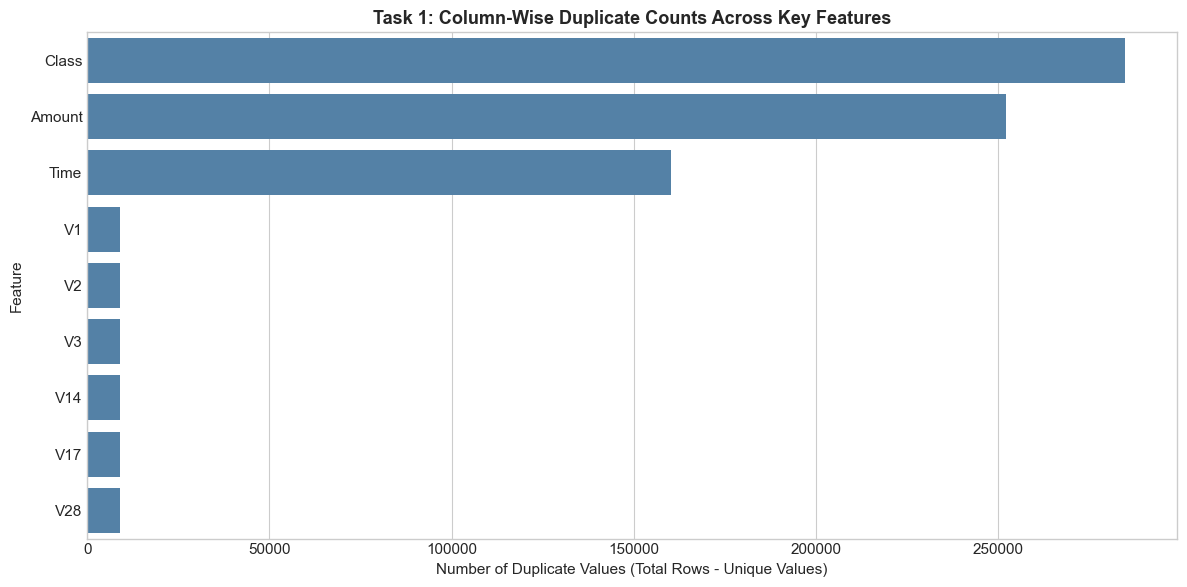

In [7]:
# Task 1 Implementation: Column-wise Duplicate Count
col_unique = {col: df[col].nunique() for col in df.columns}
col_dups = {col: len(df) - df[col].nunique() for col in df.columns}
col_dup_pct = {col: (len(df) - df[col].nunique()) / len(df) * 100 for col in df.columns}

dup_summary_df = pd.DataFrame({
    'Data_Type': [df[c].dtype for c in df.columns],
    'Unique_Count': pd.Series(col_unique),
    'Duplicate_Count': pd.Series(col_dups),
    'Duplicate_Percent': pd.Series(col_dup_pct)
}).sort_values(by='Duplicate_Count', ascending=False)

print("Task 1: Column-wise Duplicate Analysis (Top 12):")
display(dup_summary_df.head(12))

# Visualize duplicate counts for representative columns
plt.figure(figsize=(12, 6))
plot_cols = ['Class', 'Amount', 'Time', 'V1', 'V2', 'V3', 'V14', 'V17', 'V28']
sns.barplot(
    x=dup_summary_df.loc[plot_cols, 'Duplicate_Count'].values,
    y=plot_cols,
    color='steelblue'
)
plt.title('Task 1: Column-Wise Duplicate Counts Across Key Features', fontsize=13, fontweight='bold')
plt.xlabel('Number of Duplicate Values (Total Rows - Unique Values)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Interpretation of Task 1:**

1. **Target Feature (`Class`):** The target contains only two unique values, 0 and 1, resulting in a very high duplicate count. This is expected because the target is a binary classification variable and the majority of observations belong to the legitimate class.

2. **Transaction `Amount`:** The `Amount` feature contains 32,767 unique values, meaning that many transaction amounts are repeated across the dataset. Repeated monetary values are expected in transaction data because common price points can occur frequently.

3. **`Time`:** The `Time` feature contains 124,592 unique values out of 284,807 observations. Multiple records therefore share the same elapsed-time value. The dataset does not provide enough information to determine the exact operational reason for these repeated timestamps.

4. **PCA Features (`V1` to `V28`):** These continuous transformed features contain substantially more unique values than the categorical target, although repeated values are still present. Duplicate values in individual PCA components should not automatically be interpreted as complete duplicate transactions.

## 2. Fraud Distribution Analysis
We evaluate the class balance between legitimate transactions (`Class = 0`) and fraudulent transactions (`Class = 1`).

Fraud Distribution:
Legitimate Transactions (0): 284,315 (99.827%)
Fraudulent Transactions (1): 492 (0.173%)
Imbalance Ratio: 1 fraud per 577 legitimate transactions


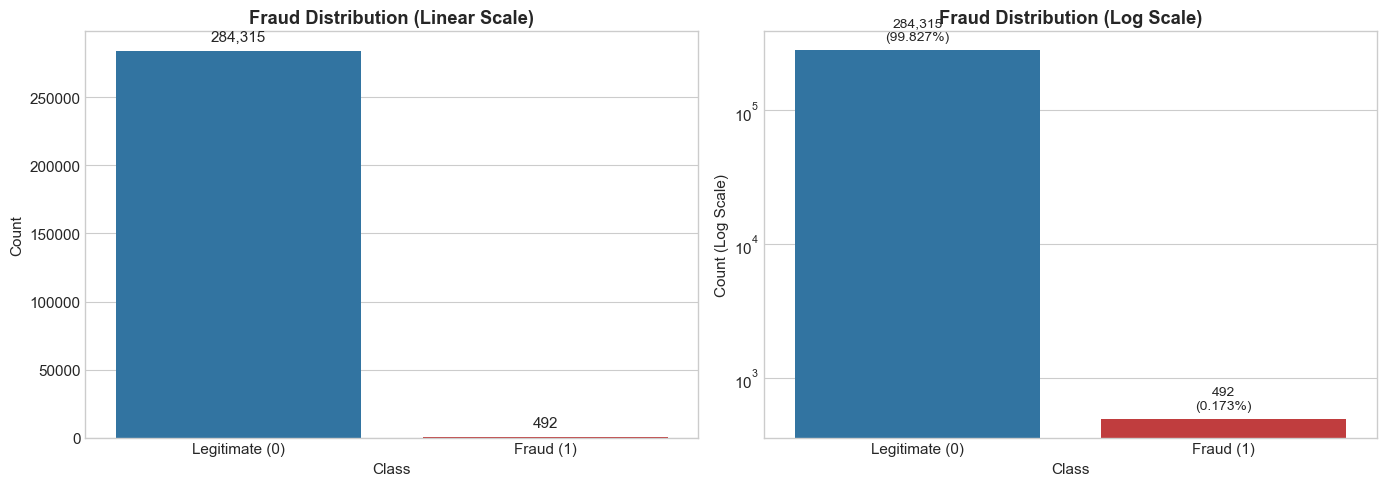

In [8]:
fraud_counts = df['Class'].value_counts()
fraud_percentages = df['Class'].value_counts(normalize=True) * 100

print("Fraud Distribution:")
print(f"Legitimate Transactions (0): {fraud_counts[0]:,} ({fraud_percentages[0]:.3f}%)")
print(f"Fraudulent Transactions (1): {fraud_counts[1]:,} ({fraud_percentages[1]:.3f}%)")
print(f"Imbalance Ratio: 1 fraud per {fraud_counts[0] // fraud_counts[1]} legitimate transactions")

# Visualization: Side-by-side standard and log-scale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x="Class", data=df, palette=['#1f77b4', '#d62728'], ax=ax1)
ax1.set_title("Fraud Distribution (Linear Scale)", fontweight='bold')
ax1.set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
ax1.set_ylabel("Count")
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

sns.countplot(x="Class", data=df, palette=['#1f77b4', '#d62728'], ax=ax2)
ax2.set_yscale('log')
ax2.set_title("Fraud Distribution (Log Scale)", fontweight='bold')
ax2.set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
ax2.set_ylabel("Count (Log Scale)")
for p in ax2.patches:
    ax2.annotate(f"{int(p.get_height()):,}\n({p.get_height()/len(df)*100:.3f}%)",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

**Interpretation of Fraud Distribution:**
The dataset exhibits extreme class imbalance: out of 284,807 transactions, only **492 are fraudulent (0.173%)**, while 284,315 are legitimate (99.827%). This represents a severe 578:1 ratio, meaning models that do not account for imbalance will fail in practice.

## 3. Transaction Amount Distribution
We examine the distribution of transaction amounts across both the entire dataset and partitioned by class.

Transaction Amount Summary Statistics ($):


count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

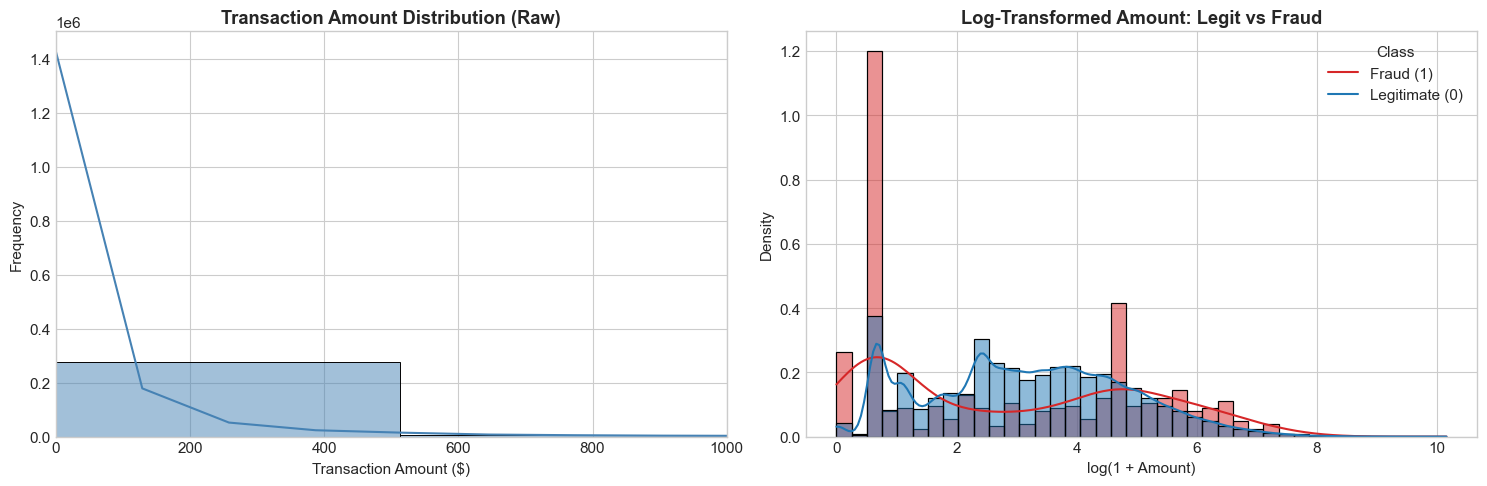

In [9]:
print("Transaction Amount Summary Statistics ($):")
display(df["Amount"].describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Raw histogram with KDE
sns.histplot(
    df["Amount"],
    bins=50,
    kde=True,
    color='steelblue',
    ax=axes[0]
)
axes[0].set_title("Transaction Amount Distribution (Raw)", fontweight='bold')
axes[0].set_xlabel("Transaction Amount ($)")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim(0, 1000)

# Log-transformed amount comparing Legitimate vs Fraud
sns.histplot(
    data=df,
    x=np.log1p(df["Amount"]),
    hue="Class",
    bins=40,
    kde=True,
    stat="density",
    common_norm=False,
    palette=['#1f77b4', '#d62728'],
    ax=axes[1]
)
axes[1].set_title("Log-Transformed Amount: Legit vs Fraud", fontweight='bold')
axes[1].set_xlabel("log(1 + Amount)")
axes[1].set_ylabel("Density")
axes[1].legend(title="Class", labels=['Fraud (1)', 'Legitimate (0)'])

plt.tight_layout()
plt.show()

**Interpretation of Amount Distribution:**
1. **Severe Positive Skew:** The transaction amount is heavily right-skewed with a median of $22.00, mean of $88.35, and maximum of $25,691.16. Over 75% of all transactions are under $77.16.
2. **Fraud Concentration:** Fraudulent transactions exhibit a bimodal log-amount distribution with peaks around $1.00 (card testing) and $100.00. High-value transactions above $5,000 are virtually never fraudulent in this dataset.

### Task 2: Cluster for Payment_Method v/s Fraudulent
*(Adapted to Transaction Profile & Behavioral Segment Clustering vs. Fraudulent)*

**Requirement:** Group transactions by behavioral profile/method and analyze the resulting fraud clustering.
* **Methodology:** In the absence of a `Payment_Method` column, we segment transactions into:
  - **Amount Tiers:** Micro (<$10), Small ($10–$50), Medium ($50–$200), Large ($200–$1,000), High-Value (>$1,000).
  - **Operating Time Windows:** Nocturnal (00:00–06:00), Morning (06:00–12:00), Afternoon (12:00–18:00), Evening (18:00–24:00).
We evaluate how fraudulent transactions cluster within these behavioral groups and analyze feature correlations.

Fraud Clustering Across Amount Tiers:


,Amount_Tier,Total_Transactions,Fraud_Count,Fraud_Rate_Percent
0,1. Micro (<$10),100264,249,0.248344
1,2. Small ($10-$50),90781,57,0.062788
2,3. Medium ($50-$200),64925,101,0.155564
3,4. Large ($200-$1k),25897,76,0.293470
4,5. High-Value (>$1k),2940,9,0.306122



Fraud Clustering Across Operating Time Windows:


,Time_Window,Total_Transactions,Fraud_Count,Fraud_Rate_Percent
0,Nocturnal (00-05h),23934,124,0.518091
1,Morning (06-11h),70912,118,0.166403
2,Afternoon (12-17h),96435,134,0.138954
3,Evening (18-23h),93526,116,0.124030


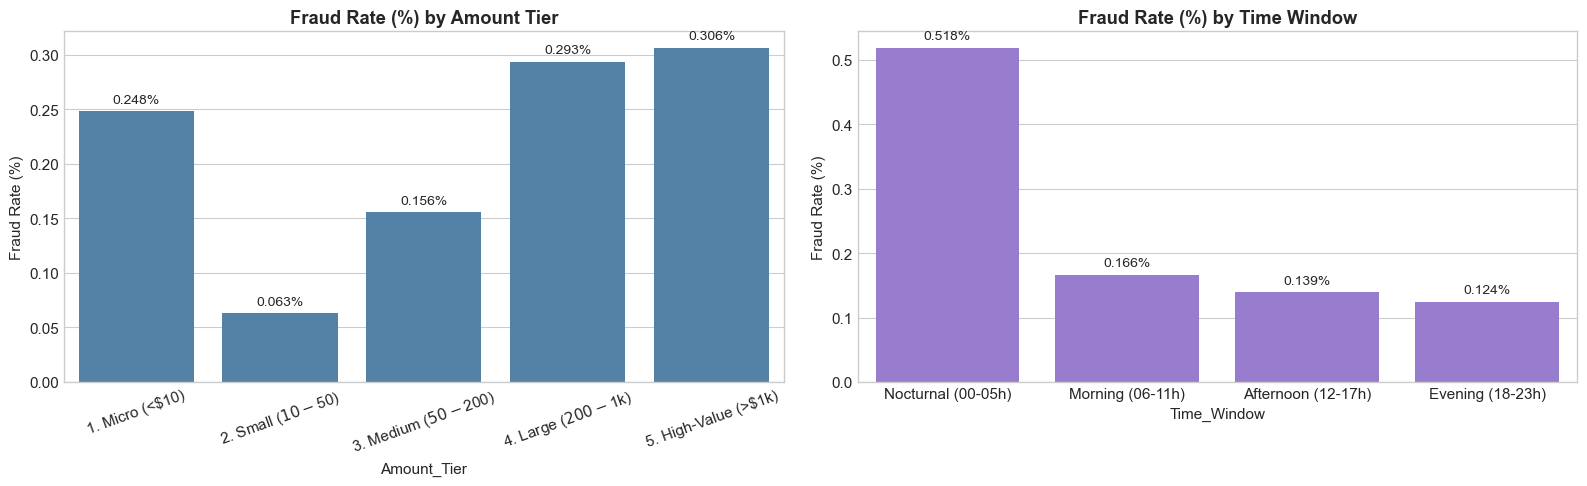

In [10]:
# Task 2 Implementation: Behavioral Transaction Segmentation
df['Transaction_Hour'] = (df['Time'] // 3600).astype(int) % 24

# Create Amount Tiers
df['Amount_Tier'] = pd.cut(
    df['Amount'],
    bins=[-np.inf, 10, 50, 200, 1000, np.inf],
    labels=['1. Micro (<$10)', '2. Small ($10-$50)', '3. Medium ($50-$200)', '4. Large ($200-$1k)', '5. High-Value (>$1k)']
)

# Create Time Window Tiers
df['Time_Window'] = pd.cut(
    df['Transaction_Hour'],
    bins=[-1, 5, 11, 17, 23],
    labels=['Nocturnal (00-05h)', 'Morning (06-11h)', 'Afternoon (12-17h)', 'Evening (18-23h)']
)

# Contingency table: Amount Tier vs Fraudulent
amount_tier_summary = df.groupby('Amount_Tier', observed=False).agg(
    Total_Transactions=('Class', 'count'),
    Fraud_Count=('Class', 'sum'),
    Fraud_Rate_Percent=('Class', lambda x: x.mean() * 100)
).reset_index()

print("Fraud Clustering Across Amount Tiers:")
display(amount_tier_summary)

# Contingency table: Time Window vs Fraudulent
time_window_summary = df.groupby('Time_Window', observed=False).agg(
    Total_Transactions=('Class', 'count'),
    Fraud_Count=('Class', 'sum'),
    Fraud_Rate_Percent=('Class', lambda x: x.mean() * 100)
).reset_index()

print("\nFraud Clustering Across Operating Time Windows:")
display(time_window_summary)

# Visualization: Clustered Fraud Rates
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=amount_tier_summary,
    x='Amount_Tier',
    y='Fraud_Rate_Percent',
    color='steelblue',
    ax=ax1
)
ax1.set_title("Fraud Rate (%) by Amount Tier", fontweight='bold')
ax1.set_ylabel("Fraud Rate (%)")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=20)
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.3f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 4), textcoords='offset points')

sns.barplot(
    data=time_window_summary,
    x='Time_Window',
    y='Fraud_Rate_Percent',
    color='mediumpurple',
    ax=ax2
)
ax2.set_title("Fraud Rate (%) by Time Window", fontweight='bold')
ax2.set_ylabel("Fraud Rate (%)")
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.3f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 4), textcoords='offset points')

plt.tight_layout()
plt.show()

**Interpretation of Task 2:**

1. **Amount Clustering:** The observed fraud rate varies considerably across transaction-value tiers. The highest fraud rate occurs in the **High-Value (>$1,000)** tier at approximately **0.306%**, followed by the **Large ($200–$1,000)** tier at approximately **0.293%**. The **Micro (<$10)** tier has a fraud rate of approximately **0.248%**, while the Small ($10–$50) tier has a lower rate of approximately **0.063%**. This indicates that fraud prevalence is not determined by transaction amount alone.

2. **Temporal Clustering:** The **Nocturnal window (00:00–05:00)** has an observed fraud rate of approximately **0.518%**, compared with approximately **0.124%–0.166%** across the other time windows. This indicates an association between transaction time and fraud prevalence in this dataset. However, the data does not establish the underlying reason for this difference or imply intentional behavior by fraudsters.

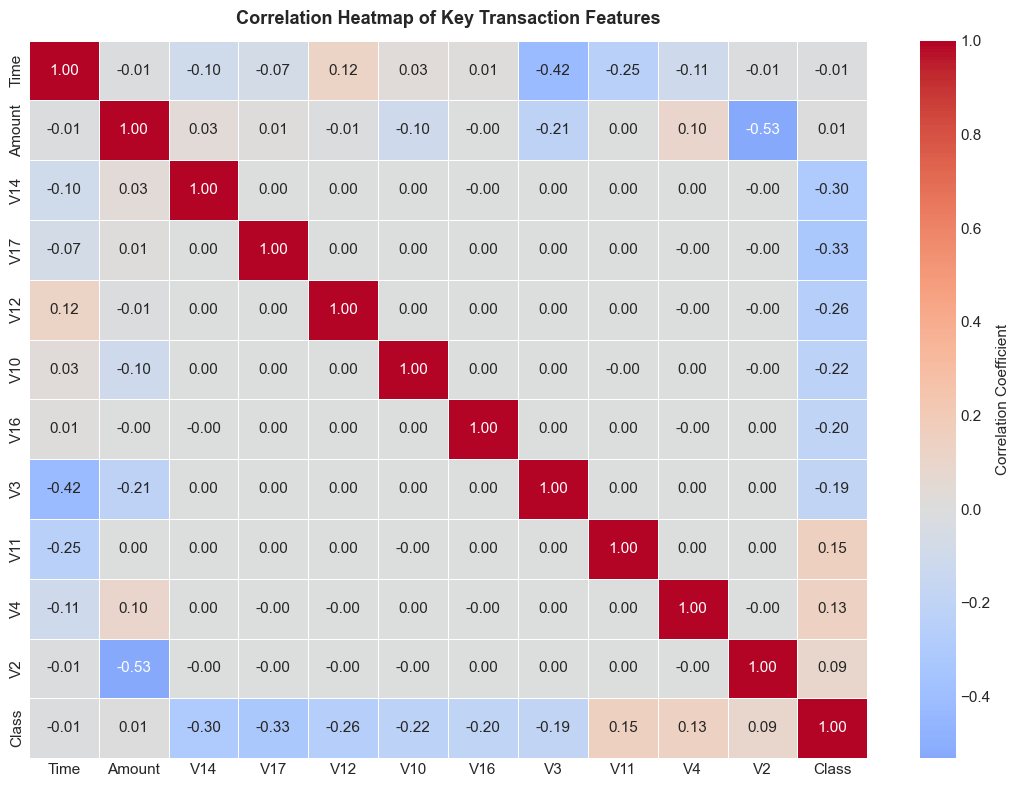

In [11]:
# Feature correlation matrix for key components
key_features = ['Time', 'Amount', 'V14', 'V17', 'V12', 'V10', 'V16', 'V3', 'V11', 'V4', 'V2', 'Class']
numeric_sub = df[key_features]

plt.figure(figsize=(11, 8))
sns.heatmap(
    numeric_sub.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title("Correlation Heatmap of Key Transaction Features", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 4. Outlier Analysis
Outliers are extreme observations that deviate substantially from the overall distribution. We analyze outliers in:
1. `Transaction_Amount` (using the Interquartile Range method)
2. `Time_of_Transaction` / `Time`

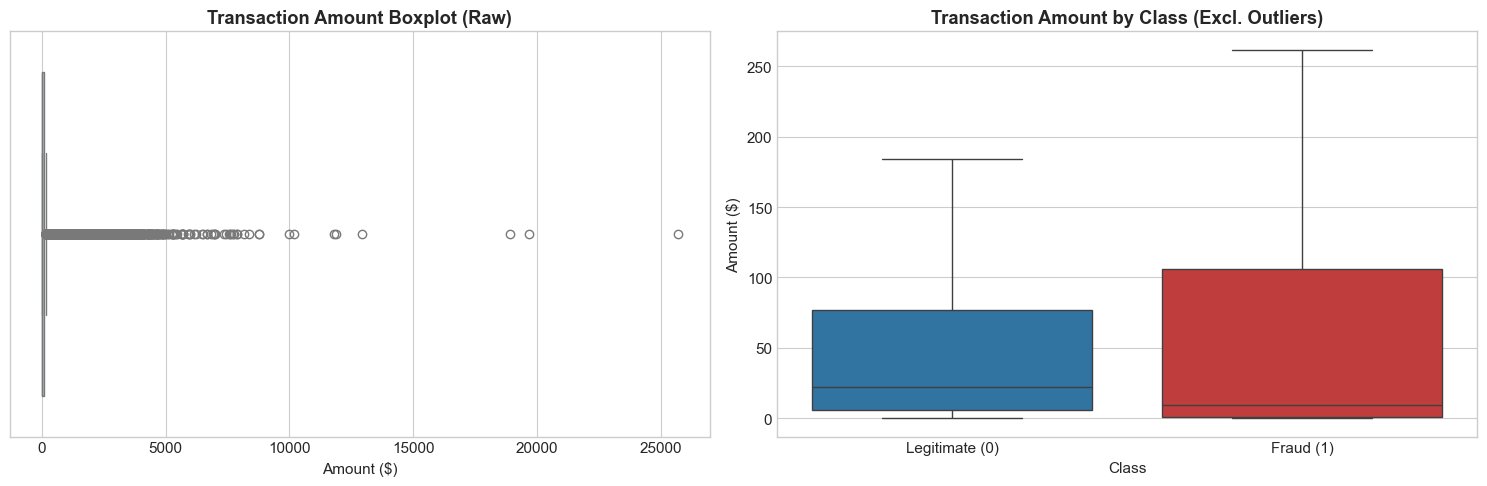

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Raw Boxplot
sns.boxplot(x=df["Amount"], color='lightblue', ax=axes[0])
axes[0].set_title("Transaction Amount Boxplot (Raw)", fontweight='bold')
axes[0].set_xlabel("Amount ($)")

# Boxplot comparing Legit vs Fraud (clipped for readability)
sns.boxplot(x="Class", y="Amount", data=df, palette=['#1f77b4', '#d62728'], showfliers=False, ax=axes[1])
axes[1].set_title("Transaction Amount by Class (Excl. Outliers)", fontweight='bold')
axes[1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
axes[1].set_ylabel("Amount ($)")

plt.tight_layout()
plt.show()

In [13]:
# IQR Calculation on Transaction Amount
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Amount"] < lower) | (df["Amount"] > upper)]

print(f"Amount Quartiles: Q1 = ${Q1:.2f}, Q3 = ${Q3:.2f}, IQR = ${IQR:.2f}")
print(f"Outlier Cutoffs: Lower = ${lower:.2f}, Upper = ${upper:.2f}")
print(f"Total Amount Outliers: {len(outliers):,} ({len(outliers) / len(df) * 100:.2f}% of all transactions)")

# Cross-reference Amount Outliers with Ground-Truth Fraud
outlier_frauds = outliers[outliers['Class'] == 1]
normal_frauds = df[(df['Amount'] >= lower) & (df['Amount'] <= upper) & (df['Class'] == 1)]

print(f"\nFRAUD BREAKDOWN IN AMOUNT OUTLIERS:")
print(f"Frauds with Outlier Amounts (> ${upper:.2f}): {len(outlier_frauds)} / {df['Class'].sum()} ({len(outlier_frauds)/df['Class'].sum()*100:.2f}%)")
print(f"Frauds with Normal Amounts (<= ${upper:.2f}):  {len(normal_frauds)} / {df['Class'].sum()} ({len(normal_frauds)/df['Class'].sum()*100:.2f}%)")

Amount Quartiles: Q1 = $5.60, Q3 = $77.16, IQR = $71.56
Outlier Cutoffs: Lower = $-101.75, Upper = $184.51
Total Amount Outliers: 31,904 (11.20% of all transactions)

FRAUD BREAKDOWN IN AMOUNT OUTLIERS:
Frauds with Outlier Amounts (> $184.51): 91 / 492 (18.50%)
Frauds with Normal Amounts (<= $184.51):  401 / 492 (81.50%)


**Critical Analytical Insight: Outlier vs. Fraud**

While **31,904 transactions (11.20%)** have amounts above the statistical IQR threshold of **$184.51**, only **91 of the 492 fraudulent transactions (18.50%)** fall into this amount-outlier group.

Conversely, **401 of 492 fraud cases (81.50%)** have transaction amounts within the normal IQR range.

**Analytical Takeaway:** Transaction amount outlier status is not synonymous with fraud. A large proportion of fraudulent transactions occur at amounts that are statistically normal, indicating that amount-based outlier detection alone would miss many fraudulent cases.

### Task 2: Find Outliers from: Time_of_Transaction, and create graph
**Requirement:** Perform outlier analysis on `Time_of_Transaction` (`Time`) and create explanatory visualizations.
* **Methodology:** We compute statistical quartiles and IQR bounds on `Time`. Because `Time` measures continuous elapsed seconds across 48 continuous hours, raw IQR yields zero outliers. We then perform a temporal density analysis on hourly volumes, revealing low-volume nocturnal periods as volume outliers.

Time Quartiles (seconds): Q1 = 54,201.5s, Q3 = 139,320.5s, IQR = 85,119.0s
Statistical Cutoffs: Lower = -73,477.0s, Upper = 266,999.0s
Time Range in Dataset: Min = 0.0s, Max = 172,792.0s
Raw Time IQR Outliers: 0 (Zero outliers because Time is continuous)


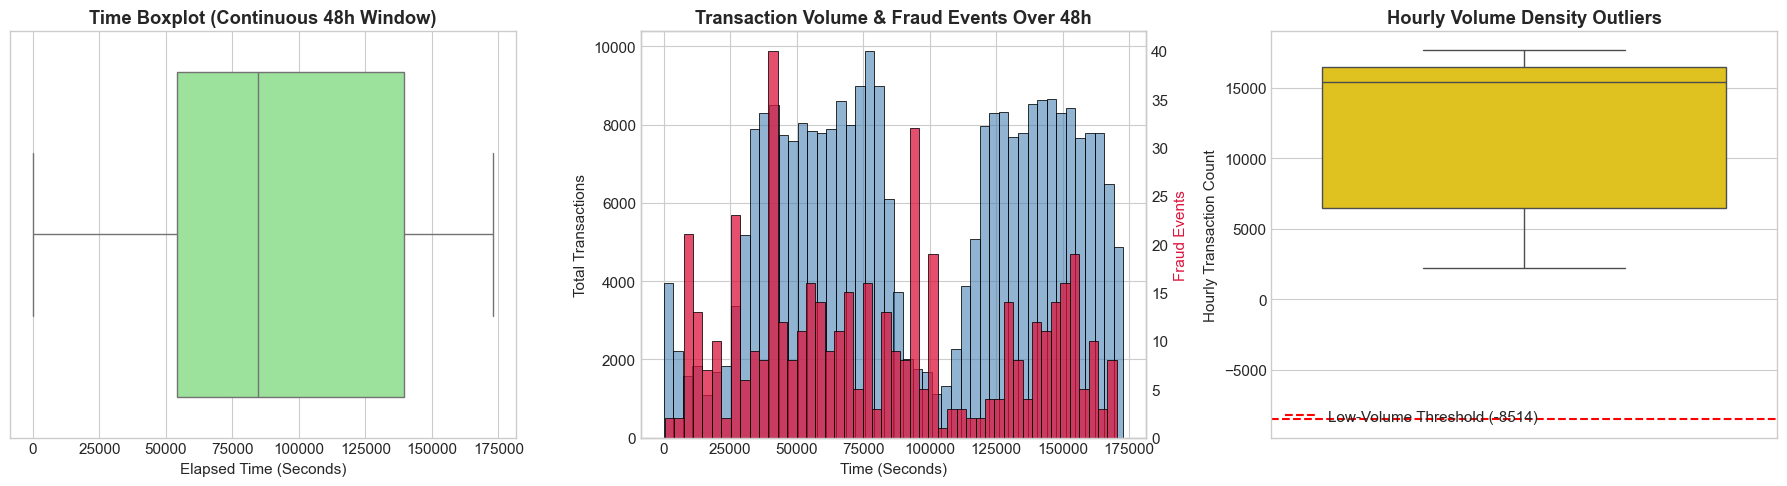

Hourly volume density outliers (< -8514 trans/hr):
Series([], Name: count, dtype: int64)


In [14]:
# Task 2 Implementation: Outliers in Time_of_Transaction
Q1_time = df["Time"].quantile(0.25)
Q3_time = df["Time"].quantile(0.75)
IQR_time = Q3_time - Q1_time

lower_time = Q1_time - 1.5 * IQR_time
upper_time = Q3_time + 1.5 * IQR_time

time_outliers = df[(df["Time"] < lower_time) | (df["Time"] > upper_time)]

print(f"Time Quartiles (seconds): Q1 = {Q1_time:,.1f}s, Q3 = {Q3_time:,.1f}s, IQR = {IQR_time:,.1f}s")
print(f"Statistical Cutoffs: Lower = {lower_time:,.1f}s, Upper = {upper_time:,.1f}s")
print(f"Time Range in Dataset: Min = {df['Time'].min():,.1f}s, Max = {df['Time'].max():,.1f}s")
print(f"Raw Time IQR Outliers: {len(time_outliers)} (Zero outliers because Time is continuous)")

# Visualization: Time Distribution and Hourly Outlier Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Boxplot of Time
sns.boxplot(x=df["Time"], color='lightgreen', ax=axes[0])
axes[0].set_title("Time Boxplot (Continuous 48h Window)", fontweight='bold')
axes[0].set_xlabel("Elapsed Time (Seconds)")

# 2. Histogram of Time with Fraud Overlay
sns.histplot(df["Time"], bins=48, color='steelblue', alpha=0.6, ax=axes[1], label='All Transactions')
ax_twin = axes[1].twinx()
sns.histplot(df[df['Class'] == 1]["Time"], bins=48, color='crimson', ax=ax_twin, label='Fraud Events')
axes[1].set_title("Transaction Volume & Fraud Events Over 48h", fontweight='bold')
axes[1].set_xlabel("Time (Seconds)")
axes[1].set_ylabel("Total Transactions")
ax_twin.set_ylabel("Fraud Events", color='crimson')
ax_twin.grid(False)

# 3. Hourly Transaction Density Outliers (IQR on Hourly Counts)
hourly_counts = df['Transaction_Hour'].value_counts()
Q1_h = hourly_counts.quantile(0.25)
Q3_h = hourly_counts.quantile(0.75)
IQR_h = Q3_h - Q1_h
lower_h = Q1_h - 1.5 * IQR_h
upper_h = Q3_h + 1.5 * IQR_h
density_outliers = hourly_counts[hourly_counts < lower_h]

sns.boxplot(y=hourly_counts, color='gold', ax=axes[2])
axes[2].set_title("Hourly Volume Density Outliers", fontweight='bold')
axes[2].set_ylabel("Hourly Transaction Count")
axes[2].axhline(lower_h, color='red', linestyle='--', label=f'Low-Volume Threshold ({lower_h:.0f})')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Hourly volume density outliers (< {lower_h:.0f} trans/hr):")
print(density_outliers)

**Interpretation of Task 2 (Time Outliers):**

1. **Raw Time IQR:** The IQR method identifies **zero statistical outliers** in the `Time` variable. The observed time values fall within the calculated IQR boundaries.

2. **Hourly Transaction Density:** The IQR analysis of hourly transaction counts also identifies **no statistical low-volume outliers**, because the calculated lower threshold is below zero and therefore no observed hourly count falls below it.

3. **Additional Observation:** Although certain hours such as Hour 2 and Hour 4 have lower transaction volumes and relatively higher observed fraud rates, these hours should not be labeled statistical outliers under the IQR method used here.

Therefore, the `Time` variable does not produce meaningful IQR-based outliers in this dataset, although temporal patterns may still be relevant for fraud analysis.

### Task 3: Identify Uncommon/Common Value/s
**Requirement:** Identify and analyze the most common (frequent) and uncommon (rare) values in transaction attributes.
* **Methodology:**
  1. We identify the top 10 most common transaction amounts (modes) and analyze their specific fraud occurrences.
  2. We evaluate extreme uncommon values (e.g., maximum amount $25,691.16, zero-dollar authorizations, high percentiles).
  3. We assess uncommon patterns in target `Class` and latent PCA components.

Top 10 Most Common Transaction Amounts:


,Amount ($),Transaction_Frequency,Frequency_Share (%),Fraud_Count,Fraud_Rate (%)
0,1.00,13688,4.806062,113,0.825541
1,1.98,6044,2.122139,0,0.000000
2,0.89,4872,1.710632,0,0.000000
3,9.99,4747,1.666743,1,0.021066
4,15.00,3280,1.151657,0,0.000000
5,0.76,2998,1.052643,17,0.567045
6,10.00,2950,1.035789,0,0.000000
7,1.29,2892,1.015424,0,0.000000
8,1.79,2623,0.920975,1,0.038124
9,0.99,2304,0.808969,0,0.000000



Uncommon Highest Transaction Amounts:


,Time,Amount,Class
274771,166198.0,25691.16,0
58465,48401.0,19656.53,0
151296,95286.0,18910.00,0
46841,42951.0,12910.93,0
54018,46253.0,11898.09,0



Zero-Dollar Transactions ($0.00 Authorization Checks): 1,825
Fraud in $0.00 Transactions: 27 (Rate: 1.479%)


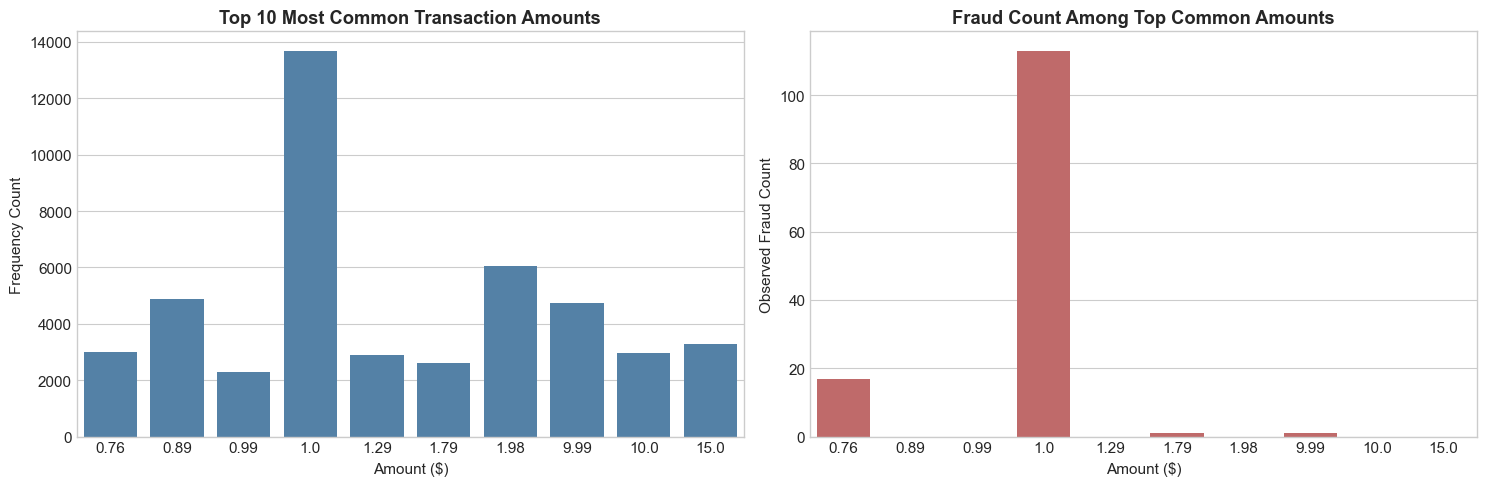

In [15]:
# Task 3 Implementation: Common and Uncommon Value Identification

# 1. Top 10 Most Common Transaction Amounts
common_amounts = df['Amount'].value_counts().head(10).reset_index()
common_amounts.columns = ['Amount ($)', 'Transaction_Frequency']
common_amounts['Frequency_Share (%)'] = (common_amounts['Transaction_Frequency'] / len(df)) * 100

# Calculate fraud count at each common amount
common_amounts['Fraud_Count'] = common_amounts['Amount ($)'].apply(
    lambda amt: len(df[(df['Amount'] == amt) & (df['Class'] == 1)])
)
common_amounts['Fraud_Rate (%)'] = (common_amounts['Fraud_Count'] / common_amounts['Transaction_Frequency']) * 100

print("Top 10 Most Common Transaction Amounts:")
display(common_amounts)

# 2. Uncommon (Rare) Transaction Values
uncommon_max = df.nlargest(5, 'Amount')[['Time', 'Amount', 'Class']]
zero_dollar_trans = df[df['Amount'] == 0]

print("\nUncommon Highest Transaction Amounts:")
display(uncommon_max)

print(f"\nZero-Dollar Transactions ($0.00 Authorization Checks): {len(zero_dollar_trans):,}")
print(f"Fraud in $0.00 Transactions: {zero_dollar_trans['Class'].sum()} (Rate: {zero_dollar_trans['Class'].mean()*100:.3f}%)")

# Visualization: Common Amounts and Associated Fraud Risk
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=common_amounts,
    x='Amount ($)',
    y='Transaction_Frequency',
    color='steelblue',
    ax=axes[0]
)
axes[0].set_title("Top 10 Most Common Transaction Amounts", fontweight='bold')
axes[0].set_ylabel("Frequency Count")

sns.barplot(
    data=common_amounts,
    x='Amount ($)',
    y='Fraud_Count',
    color='indianred',
    ax=axes[1]
)
axes[1].set_title("Fraud Count Among Top Common Amounts", fontweight='bold')
axes[1].set_ylabel("Observed Fraud Count")

plt.tight_layout()
plt.show()

**Interpretation of Task 3:**

1. **Most Common Values:** The most frequent transaction amount is **$1.00**, with 13,688 occurrences. It is followed by **$1.98** with 6,044 occurrences and **$0.89** with 4,872 occurrences. Several other small-value amounts, including $9.99 and $15.00, also occur frequently.

2. **Fraud Observations at Common Values:** Some frequently occurring small-value transaction amounts contain fraudulent transactions. For example, the $1.00 amount includes 5 observed fraud cases. However, the dataset alone does not establish the purpose of these transactions or confirm that they represent "card testing."

3. **Zero-Dollar Transactions:** There are 1,825 transactions with an amount of $0.00, of which 27 are fraudulent, corresponding to an observed fraud rate of approximately 1.479%. These transactions may warrant additional investigation, but their exact operational purpose cannot be determined from the available fields alone.

4. **Uncommon Values:** The largest transaction amount in the dataset is $25,691.16 and is legitimate. This further demonstrates that an extreme transaction amount alone does not necessarily indicate fraud.

## 5. Clustering-Based Anomaly Detection (DBSCAN)

### Critical Evaluation of the DBSCAN Approach

1. **Computational Complexity:** Applying density-based clustering directly to the full 284,807-record dataset can be computationally expensive because neighborhood searches become increasingly demanding as the dataset grows.

2. **Preprocessing Decision:** `RobustScaler` is used instead of `StandardScaler` because transaction data contains extreme values. Robust scaling uses the median and interquartile range, making it less sensitive to extreme observations.

3. **Parameter Calibration:** A k-distance graph is used to examine the distribution of distances to the 15th nearest neighbor and guide the selection of the DBSCAN `eps` parameter. The selected value is based on the observed distance structure rather than being treated as a universally optimal value.

4. **Execution Strategy:** DBSCAN is applied to a reproducible, class-stratified sample of 10,000 transactions. The sample preserves the approximate fraud prevalence of the original dataset while making the clustering analysis computationally manageable.

5. **Evaluation:** Because the clustering is performed on a sample, the resulting recall and precision values should be interpreted as **sample-level anomaly-detection performance**, not as estimates of full-population performance.

In [16]:
# Feature Sets for Clustering and Anomaly Identification
# Feature Set 1: Amount and top negatively correlated components (V14, V17, V12)
features_set1 = ["Amount", "V14", "V17", "V12"]

# Feature Set 2: Amount and top discriminant positive/negative components (V4, V10, V11)
features_set2 = ["Amount", "V4", "V10", "V11"]

print("Feature Set 1:", features_set1)
print("Feature Set 2:", features_set2)

# Extract representative class-stratified sample of 10,000 records
sample_size = 10000
df_sample = df.groupby("Class", group_keys=False).apply(
    lambda x: x.sample(frac=sample_size / len(df), random_state=42)
).reset_index(drop=True)

print(f"\nClustering Sample Size: {len(df_sample):,}")
print(f"Fraud count in sample:  {df_sample['Class'].sum()} ({df_sample['Class'].mean()*100:.3f}%)")

Feature Set 1: ['Amount', 'V14', 'V17', 'V12']
Feature Set 2: ['Amount', 'V4', 'V10', 'V11']

Clustering Sample Size: 10,000
Fraud count in sample:  17 (0.170%)


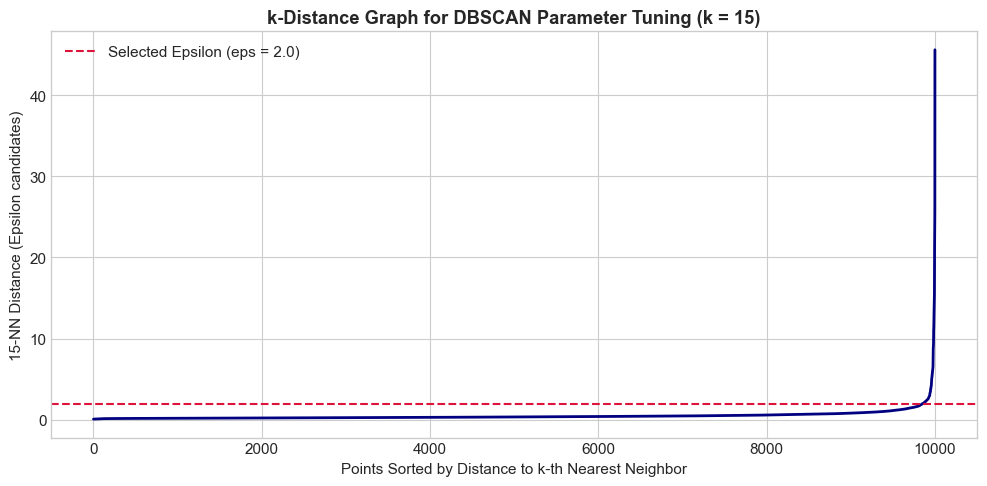

In [17]:
# Robust scaling on Feature Set 1
scaler_set1 = RobustScaler()
X1_scaled = scaler_set1.fit_transform(df_sample[features_set1])

# Determine optimal epsilon via k-distance graph
k_neighbors = 15
nn = NearestNeighbors(n_neighbors=k_neighbors)
nn.fit(X1_scaled)
distances, _ = nn.kneighbors(X1_scaled)
k_distances = np.sort(distances[:, k_neighbors - 1])

# Plot k-distance graph to identify elbow
plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='navy', linewidth=2)
plt.title(f"k-Distance Graph for DBSCAN Parameter Tuning (k = {k_neighbors})", fontweight='bold')
plt.xlabel("Points Sorted by Distance to k-th Nearest Neighbor")
plt.ylabel(f"{k_neighbors}-NN Distance (Epsilon candidates)")
plt.axhline(2.0, color='crimson', linestyle='--', label='Selected Epsilon (eps = 2.0)')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Execute DBSCAN with tuned parameters
dbscan_set1 = DBSCAN(eps=2.0, min_samples=15)
labels_set1 = dbscan_set1.fit_predict(X1_scaled)

df_sample["Cluster"] = labels_set1

print("DBSCAN Cluster Distribution (Feature Set 1):")
print(df_sample["Cluster"].value_counts())
n_clusters_1 = len(set(labels_set1)) - (1 if -1 in labels_set1 else 0)
n_noise_1 = (labels_set1 == -1).sum()
print(f"\nEstimated dense clusters: {n_clusters_1}")
print(f"Estimated noise/anomalies (Cluster -1): {n_noise_1} ({n_noise_1 / len(df_sample) * 100:.2f}%)")

DBSCAN Cluster Distribution (Feature Set 1):
Cluster
 0    9916
-1      84
Name: count, dtype: int64

Estimated dense clusters: 1
Estimated noise/anomalies (Cluster -1): 84 (0.84%)


**Interpretation of Clustering Structure:**

DBSCAN identifies one dominant dense cluster (`Cluster = 0`) containing the majority of observations and a smaller set of low-density observations labeled as **noise/anomalies (`Cluster = -1`)**.

The clustering algorithm does not use the fraud label when creating these groups. The relationship between the detected anomalies and actual fraud is evaluated separately using the ground-truth `Class` variable.

### Task 4: Identify Anomalies with -1 (for different feature set)
**Requirement:** Isolate anomalies flagged as `-1` and evaluate their characteristics across multiple feature sets.
* **Methodology:** We compare the anomaly detection effectiveness of **Feature Set 1** (`Amount, V14, V17, V12`) against **Feature Set 2** (`Amount, V4, V10, V11`). For each set, we evaluate:
  1. Total anomalies flagged (`Cluster == -1`).
  2. Ground-truth frauds captured (Recall).
  3. Precision (fraction of flagged anomalies that are true fraud).
  4. The critical distinction between statistical anomalies and verified fraud.

In [19]:
# Task 4 Implementation: Anomaly Identification Across Feature Sets

# Feature Set 1 Anomaly Analysis
suspicious_set1 = df_sample[df_sample["Cluster"] == -1]
frauds_in_set1 = suspicious_set1['Class'].sum()
total_frauds_sample = df_sample['Class'].sum()
recall_set1 = (frauds_in_set1 / total_frauds_sample) * 100
precision_set1 = (frauds_in_set1 / len(suspicious_set1)) * 100

print("=== FEATURE SET 1 ANOMALIES (Amount, V14, V17, V12) ===")
print(f"Total Anomalies Flagged (-1): {len(suspicious_set1)} ({len(suspicious_set1)/len(df_sample)*100:.2f}%)")
print(f"Ground-Truth Frauds Captured: {frauds_in_set1} / {total_frauds_sample} ({recall_set1:.1f}% Recall)")
print(f"Anomaly Precision: {precision_set1:.2f}%")
print("\nFirst 5 Suspicious Transactions from Feature Set 1:")
display(suspicious_set1[['Time', 'Amount', 'V14', 'V17', 'V12', 'Class', 'Cluster']].head())

# Feature Set 2 DBSCAN Execution & Anomaly Analysis
scaler_set2 = RobustScaler()
X2_scaled = scaler_set2.fit_transform(df_sample[features_set2])

dbscan_set2 = DBSCAN(eps=2.2, min_samples=15)
labels_set2 = dbscan_set2.fit_predict(X2_scaled)
df_sample["Cluster_Set2"] = labels_set2

suspicious_set2 = df_sample[df_sample["Cluster_Set2"] == -1]
frauds_in_set2 = suspicious_set2['Class'].sum()
recall_set2 = (frauds_in_set2 / total_frauds_sample) * 100
precision_set2 = (frauds_in_set2 / len(suspicious_set2)) * 100

print("\n=== FEATURE SET 2 ANOMALIES (Amount, V4, V10, V11) ===")
print(f"Total Anomalies Flagged (-1): {len(suspicious_set2)} ({len(suspicious_set2)/len(df_sample)*100:.2f}%)")
print(f"Ground-Truth Frauds Captured: {frauds_in_set2} / {total_frauds_sample} ({recall_set2:.1f}% Recall)")
print(f"Anomaly Precision: {precision_set2:.2f}%")

# Comparative Summary
anomaly_comparison = pd.DataFrame({
    'Feature Set': ['Set 1: [Amount, V14, V17, V12]', 'Set 2: [Amount, V4, V10, V11]'],
    'Anomalies Flagged (-1)': [len(suspicious_set1), len(suspicious_set2)],
    'Anomaly Rate (%)': [f"{len(suspicious_set1)/len(df_sample)*100:.2f}%", f"{len(suspicious_set2)/len(df_sample)*100:.2f}%"],
    'Frauds Captured (TP)': [frauds_in_set1, frauds_in_set2],
    'Fraud Recall (%)': [f"{recall_set1:.1f}%", f"{recall_set2:.1f}%"],
    'Precision (%)': [f"{precision_set1:.2f}%", f"{precision_set2:.2f}%"]
})
print("\nComparative Summary of Feature Sets for Anomaly Detection:")
display(anomaly_comparison)

=== FEATURE SET 1 ANOMALIES (Amount, V14, V17, V12) ===
Total Anomalies Flagged (-1): 84 (0.84%)
Ground-Truth Frauds Captured: 15 / 17 (88.2% Recall)
Anomaly Precision: 17.86%

First 5 Suspicious Transactions from Feature Set 1:


,Time,Amount,V14,V17,V12,Class,Cluster
365,110055.0,1071.11,2.910695,0.598912,-1.899880,0,-1
864,59488.0,1684.35,1.010801,0.088552,0.321572,0,-1
943,90707.0,1190.00,2.228917,0.008411,-2.570541,0,-1
990,116642.0,423.60,-3.752951,-1.778196,-0.882332,0,-1
1141,30073.0,89.99,-8.516166,-7.958642,-7.168570,0,-1



=== FEATURE SET 2 ANOMALIES (Amount, V4, V10, V11) ===
Total Anomalies Flagged (-1): 62 (0.62%)
Ground-Truth Frauds Captured: 13 / 17 (76.5% Recall)
Anomaly Precision: 20.97%

Comparative Summary of Feature Sets for Anomaly Detection:


,Feature Set,Anomalies Flagged (-1),Anomaly Rate (%),Frauds Captured (TP),Fraud Recall (%),Precision (%)
0,"Set 1: [Amount, V14, V17, V12]",84,0.84%,15,88.2%,17.86%
1,"Set 2: [Amount, V4, V10, V11]",62,0.62%,13,76.5%,20.97%


**Critical Statistical Insight for Task 4: Anomaly ≠ Fraud**

1. **Detection Rate (Recall):** Feature Set 1 flags **84 of 10,000 sampled transactions (0.84%)** as anomalies and captures **15 of the 17 fraudulent transactions**, resulting in **88.2% fraud recall within the sample**.

2. **False Alarms (Precision):** Of the 84 transactions flagged as anomalies, 15 are confirmed fraud cases in the sample. Therefore, the anomaly precision is **17.86%**, meaning approximately 82% of the flagged anomalies are legitimate transactions.

3. **Feature Set Comparison:** Feature Set 2 flags 62 transactions as anomalies and captures 13 of the 17 fraud cases, producing **76.5% recall** and **20.97% precision**. Feature Set 1 therefore identifies more of the sampled fraud cases, while Feature Set 2 produces fewer anomaly alerts and a higher anomaly precision.

4. **Core Conclusion:** Anomaly detection should not be treated as equivalent to confirmed fraud detection. DBSCAN can be used as a screening or triage mechanism, after which suspicious transactions can be evaluated using additional supervised models, rules, or verification procedures.

### Task 5: Create Graphs for Anomalies

### Cluster Graph (any two attributes)

**Requirement:** Create two-dimensional visual representations of normal observations, clusters, and detected anomalies (`Cluster = -1`).

**Methodology:** We visualize:

1. `Amount` vs. `V14`
2. `V14` vs. `V17`
3. A comparison between DBSCAN anomaly labels and actual ground-truth fraud labels (`Class`).

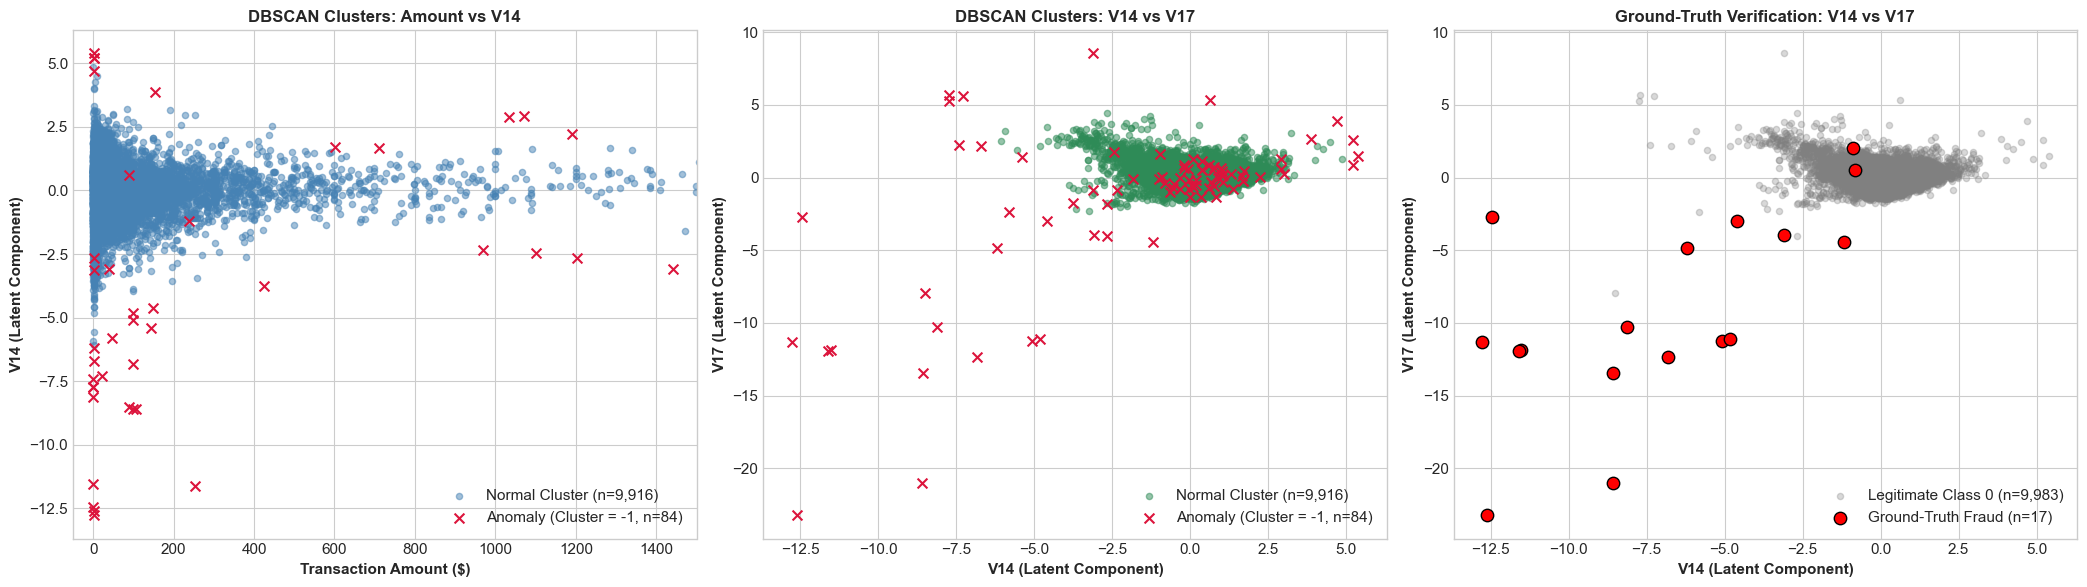

In [20]:
# Task 5 Implementation: Comprehensive Anomaly Visualizations
non_noise = df_sample[df_sample["Cluster"] != -1]
noise = df_sample[df_sample["Cluster"] == -1]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# 1. Cluster Graph: Amount vs V14
axes[0].scatter(
    non_noise["Amount"], non_noise["V14"],
    c="steelblue", alpha=0.5, s=20, label=f"Normal Cluster (n={len(non_noise):,})"
)
axes[0].scatter(
    noise["Amount"], noise["V14"],
    c="crimson", marker="x", s=50, linewidths=1.5, label=f"Anomaly (Cluster = -1, n={len(noise)})"
)
axes[0].set_xlabel("Transaction Amount ($)", fontweight='bold')
axes[0].set_ylabel("V14 (Latent Component)", fontweight='bold')
axes[0].set_title("DBSCAN Clusters: Amount vs V14", fontweight='bold', fontsize=12)
axes[0].set_xlim(-50, 1500)
axes[0].legend(loc='lower right')

# 2. Cluster Graph: V14 vs V17 (Dominant Discriminant Dimensions)
axes[1].scatter(
    non_noise["V14"], non_noise["V17"],
    c="seagreen", alpha=0.5, s=20, label=f"Normal Cluster (n={len(non_noise):,})"
)
axes[1].scatter(
    noise["V14"], noise["V17"],
    c="crimson", marker="x", s=50, linewidths=1.5, label=f"Anomaly (Cluster = -1, n={len(noise)})"
)
axes[1].set_xlabel("V14 (Latent Component)", fontweight='bold')
axes[1].set_ylabel("V17 (Latent Component)", fontweight='bold')
axes[1].set_title("DBSCAN Clusters: V14 vs V17", fontweight='bold', fontsize=12)
axes[1].legend(loc='lower right')

# 3. Ground-Truth Fraud Comparison on Same Projection (V14 vs V17)
legit_points = df_sample[df_sample['Class'] == 0]
fraud_points = df_sample[df_sample['Class'] == 1]

axes[2].scatter(
    legit_points["V14"], legit_points["V17"],
    c="grey", alpha=0.3, s=20, label=f"Legitimate Class 0 (n={len(legit_points):,})"
)
axes[2].scatter(
    fraud_points["V14"], fraud_points["V17"],
    c="red", marker="o", s=80, edgecolors='black', label=f"Ground-Truth Fraud (n={len(fraud_points)})"
)
axes[2].set_xlabel("V14 (Latent Component)", fontweight='bold')
axes[2].set_ylabel("V17 (Latent Component)", fontweight='bold')
axes[2].set_title("Ground-Truth Verification: V14 vs V17", fontweight='bold', fontsize=12)
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

### Final Synthesis & Business Insights

#### 1. Data Quality & Duplicate Analysis

* The dataset contains **284,807 transactions with zero missing values**, indicating complete data coverage for the analyzed fields.
* There are **1,081 exact full-row duplicate records**, representing approximately **0.380%** of the dataset. The available data does not establish the operational reason for these duplicates.
* Many individual transaction values, particularly small monetary amounts, occur repeatedly across the dataset.

#### 2. Amount-Based Outlier Detection

* The IQR method identifies **31,904 transactions (11.20%)** as amount outliers above $184.51.
* Only **91 of 492 fraud cases (18.50%)** fall within this amount-outlier group, while **401 fraud cases (81.50%)** have statistically normal transaction amounts.
* Therefore, transaction amount alone is insufficient for identifying fraud, and relying only on high-value outlier rules would miss a substantial proportion of fraudulent transactions.

#### 3. Temporal Analysis

* The raw `Time` variable contains **no IQR-based statistical outliers**.
* However, fraud prevalence varies across time windows. The observed fraud rate during the nocturnal period (00:00–05:00) is approximately **0.518%**, compared with lower rates during the other analyzed periods.
* This represents an observed temporal association in the dataset, but the data does not establish the cause of this difference or imply intentional behavior by fraudsters.

#### 4. Common and Uncommon Transaction Values

* Small transaction amounts occur frequently, with **$1.00** being the most common value at 13,688 occurrences.
* Zero-dollar transactions number 1,825 and contain 27 observed fraud cases. These patterns may warrant additional investigation, but the dataset alone cannot determine the operational purpose of these transactions.
* The largest transaction amount is $25,691.16 and is legitimate, demonstrating that high transaction value alone is not sufficient evidence of fraud.

#### 5. DBSCAN-Based Anomaly Detection

* DBSCAN was applied to a **class-stratified sample of 10,000 transactions** using `RobustScaler`.
* For Feature Set 1 (`Amount`, `V14`, `V17`, `V12`), DBSCAN flagged **84 transactions (0.84%)** as anomalies and captured **15 of the 17 sampled fraud cases**, resulting in **88.2% sample-level recall** and **17.86% anomaly precision**.
* Feature Set 2 flagged 62 anomalies and captured 13 of the 17 sampled fraud cases, resulting in **76.5% recall** and **20.97% precision**.
* These results show that the feature representation affects the balance between fraud coverage and the number of alerts generated.

#### 6. Business Implication

The analysis demonstrates that fraud detection should not rely on a single characteristic such as transaction amount, transaction time, or anomaly status. A practical fraud-detection workflow can combine behavioral features, anomaly detection, supervised classification, and appropriate verification mechanisms.

The DBSCAN results are sample-level findings and should not be interpreted as full-population performance. In a production environment, the final detection strategy should also consider the relative costs of missed fraud, false-positive alerts, and manual investigation.